In [1]:
#from scipy import constants as const
import numpy as np
from scipy import constants as const
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [8, 4]

import oreonspy as op
from oreonspy import utils as op_ut

Verify the critical velocity as function of merit for the nonlinear behaviour during transient over the cavity resonance. We plot the critical velocity value in the range of interest for the cavity space between 150 and 1000 Finesse and 50m to 3km length.

In [ ]:
number_of_cavities = 10000

# Define the ranges for the parameters
parameter_grid = int(np.floor(np.power(number_of_cavities, 1/4)))
print(parameter_grid)

L_min = 50
L_max = 3000
L_values = np.linspace(L_min, L_max, parameter_grid-1)  # Less one value

Finesse_min = 150
Finesse_max = 1000
Finesse_values = np.linspace(Finesse_min, Finesse_max, parameter_grid+1)  # One more value

10


In [ ]:
# LASER
E_in_avg = 1

INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode


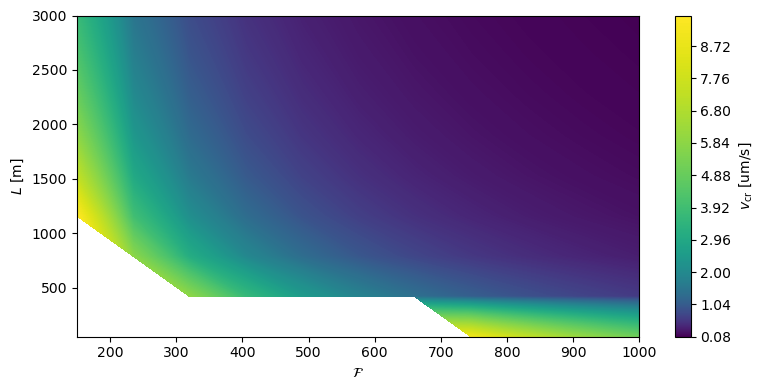

In [4]:
import matplotlib

# max_v_cr to a reslistic value set to 10um/s which is the relistic value for the ARM cavities in Virgo
# 0.3 um/s threshold for dynamic effects arise for Virgo ARM cavities
# 1.4 um/s velocity for succesful lock acquisition in Advanced Virgo
max_v_cr = 10  # um/s

# Create a meshgrid for r_a and L values
Finesse_mesh, L_mesh = np.meshgrid(Finesse_values, L_values)

# Calculate v_cr for each combination of r_a and L
v_cr_values = np.zeros_like(Finesse_mesh)
for i in range(Finesse_mesh.shape[0]):
    for j in range(Finesse_mesh.shape[1]):
        v_cr_val = op_ut.critical_velocity(Finesse_mesh[i, j], L_mesh[i, j], op_ut.lambd)*1000000
        v_cr_values[i, j] = v_cr_val if v_cr_val < max_v_cr else np.inf

# Plot the color map
plt.figure()
plt.contourf(Finesse_mesh, L_mesh, v_cr_values, 1000, cmap='viridis', norm='asinh',nchunk=200)
plt.colorbar(label='$v_\mathrm{cr}$ [um/s]')
plt.xlabel('$\mathcal{F}$')
plt.ylabel('$L$ [m]')
#plt.title('Critical velocity as a function of Finesse and Cavity length')
#plt.show()
plt.tight_layout()
plt.savefig('v_cr_color_map.pdf')

In [6]:
cavity = op.Cavity(t_a=0.014, r_a=0.999, r_b=0.999995, L=3000, debug=False)
print(cavity.Finesse())
print(cavity.tau())

def v_cr_test(cavity):
    """
    Compute the critical velocity for the cavity Eq. 2.46
    """
    return op_ut.lambd / (2. * cavity.Finesse() * cavity.tau())  # In [m/s]!

print("v_cr Eq. 2.46 = {0}".format(v_cr_test(cavity)))

op_ut.critical_velocity(cavity.Finesse(), cavity.__L__, op_ut.lambd)

3124.407200338082
0.019913776483329676
v_cr Eq. 2.46 = 8.550477610227801e-09


8.554520655283141e-09

INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode


(9, 11)
(9, 11)


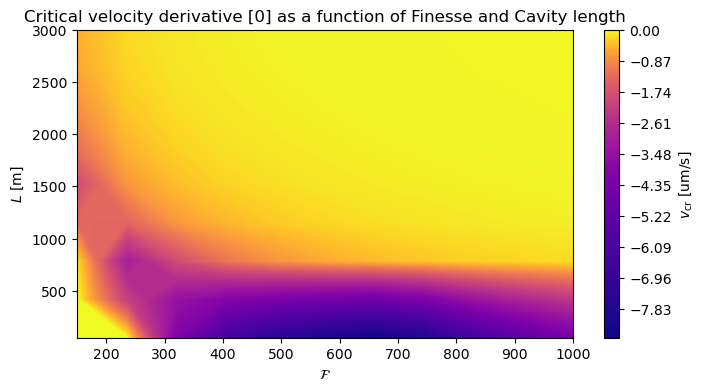

Text(0.5, 1.0, 'Critical velocity derivative [1] as a function of Finesse and Cavity length')

INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode


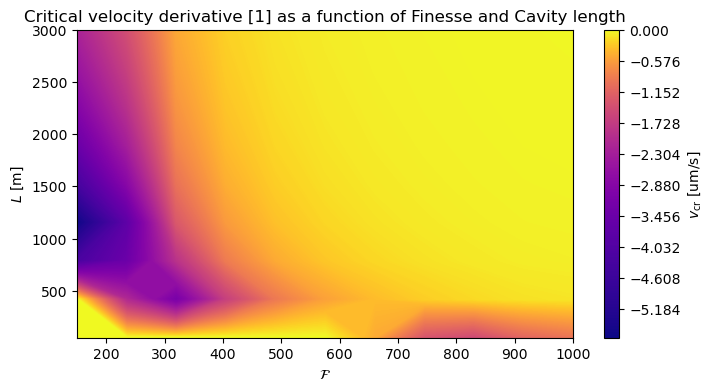

In [7]:
v_cr_values[v_cr_values == np.inf] = 10
print(np.shape(v_cr_values))

v_cr_der = np.gradient(v_cr_values)

print(np.shape(v_cr_der[0]))

# Plot the color map
plt.figure()
plt.contourf(Finesse_mesh, L_mesh, v_cr_der[0], 1000, cmap='plasma', norm='asinh',nchunk=200)
plt.colorbar(label='$v_\mathrm{cr}$ [um/s]')
plt.xlabel('$\mathcal{F}$')
plt.ylabel('$L$ [m]')
plt.title('Critical velocity derivative [0] as a function of Finesse and Cavity length')
plt.show()
plt.tight_layout()

plt.contourf(Finesse_mesh, L_mesh, v_cr_der[1], 1000, cmap='plasma', norm='asinh',nchunk=200)
plt.colorbar(label='$v_\mathrm{cr}$ [um/s]')
plt.xlabel('$\mathcal{F}$')
plt.ylabel('$L$ [m]')
plt.title('Critical velocity derivative [1] as a function of Finesse and Cavity length')



In [ ]:
print(np.shape(L_mesh))
#print(L_mesh)

print(np.shape(v_cr_der[1:][0]))
#print(v_cr_der[0:][0])

v_cr_der[0][v_cr_der[0] == 0.] = 0.33  # First direction derivative
v_cr_der[1][v_cr_der[1] == 0.] = 0.33  # Second direction derivative

v_cr_L_der = v_cr_der[0]  # Length - Verified by the number of "infinite" values
v_cr_F_der = v_cr_der[1]  # Finesse - Verified by the number of "infinite" values

F_distances = 1/np.abs(v_cr_F_der)
L_distances = 1/np.abs(v_cr_L_der)

F_coords = np.cumsum(F_distances, axis=1)
L_coords = np.cumsum(L_distances, axis=0)

F_coords_maxs = np.max(F_coords, axis=1)
L_coords_maxs = np.max(L_coords, axis=0)

F_coords_mins = np.min(F_coords, axis=1)
L_coords_mins = np.min(L_coords, axis=0)

F_coords_norm = None
for id, F_co in enumerate(F_coords):
    norm = (F_co - F_co[0]) * (Finesse_max - Finesse_min)/(F_coords_maxs[id]-F_coords_mins[id]) + Finesse_min
    #print(norm)
    if F_coords_norm is not None:
        F_coords_norm = np.vstack([F_coords_norm, norm])
    else:
        F_coords_norm = norm

L_coords_norm = None
for id, L_co in enumerate(L_coords.T):
    norm = (L_co - L_co[0]) * (L_max - L_min)/(L_coords_maxs[id]-L_coords_mins[id]) + L_min
    print(norm)
    if L_coords_norm is not None:
        L_coords_norm = np.vstack([L_coords_norm, norm])
    else:
        L_coords_norm = norm

(9, 11)
(9, 11)
[  50.          632.95653558 1671.81165611 1814.37343337 1916.96950243
 2078.63403883 2312.10941761 2630.13801381 3000.        ]
[  50.          133.60684546  191.93681099  319.16934998  551.15022343
  916.69132752 1444.60455844 2163.70181239 3000.        ]
[  50.           78.33512279  130.74896822  260.75391085  497.78965958
  871.29592332 1410.71241097 2145.47883144 3000.        ]
[  50.           65.19600594  117.84556343  248.43515563  486.53688576
  861.72285701 1403.56517259 2141.63593571 3000.        ]
[  50.           59.66399686  112.41279703  243.24854632  481.79909038
  857.69227486 1400.5559454  2140.01794766 3000.        ]
[  50.           56.74299027  109.54419248  240.50991743  479.29744383
  855.56405041 1398.96701591 2139.16361902 3000.        ]
[  50.           54.9929432   107.82554076  238.86913732  477.79864569
  854.28897867 1398.01504906 2138.65176967 3000.        ]
[  50.           54.29752592  107.14259907  238.21713952  477.20306735
  853.7823

In [10]:
#print(Finesse_mesh)  # Finesse_mesh[i] contains growing numbers
#print((F_coords_maxs))

#print(L_mesh)  # L_mesh[i] contains constant numbers numbers
print((v_cr_L_der))

[[ 0.33        0.33       -4.15754076 -6.35257595 -7.50824988 -8.19048927
  -8.62656184 -7.9496233  -6.40476166 -5.27007766 -4.41224113]
 [ 0.33       -2.11973335 -3.44664774 -4.03024837 -4.33751088 -4.51889993
  -4.63483985 -4.22718064 -3.4057066  -2.80234289 -2.34619171]
 [-0.18518045 -3.03830488 -1.86327079 -1.16323253 -0.79466626 -0.57708721
  -0.43801541 -0.34376749 -0.27696267 -0.22789525 -0.19079962]
 [-1.3494196  -1.39291584 -0.75121134 -0.46897825 -0.32038408 -0.23266315
  -0.17659384 -0.13859609 -0.11166251 -0.09188009 -0.07692432]
 [-1.87507824 -0.76396048 -0.41201037 -0.25721643 -0.17571828 -0.12760674
  -0.09685489 -0.07601459 -0.06124257 -0.05039268 -0.04219001]
 [-1.1899682  -0.48482706 -0.26147135 -0.16323552 -0.1115149  -0.0809822
  -0.06146636 -0.04824063 -0.03886596 -0.03198036 -0.02677476]
 [-0.8239655  -0.3357071  -0.18104969 -0.1130286  -0.07721587 -0.05607422
  -0.04256094 -0.03340309 -0.02691182 -0.02214405 -0.01853955]
 [-0.6049005  -0.24645376 -0.1329146  -0.0

INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode


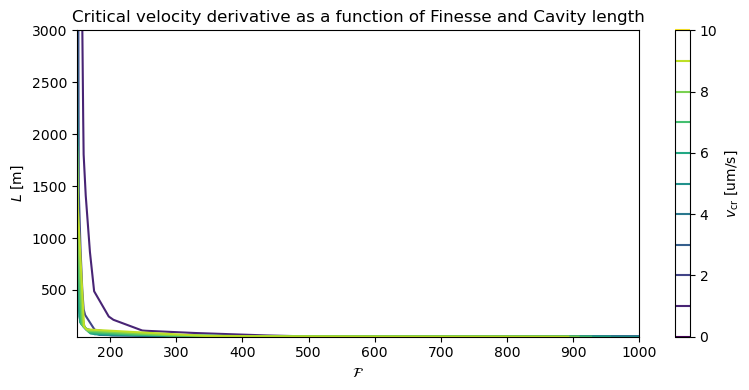

In [12]:
# Plot the color map
plt.figure()
#plt.contourf(F_coords_norm, L_coords_norm.T, v_cr_values, 1000, cmap='plasma', norm='asinh')
plt.contour(F_coords_norm, L_coords_norm.T, v_cr_values, 10)

plt.colorbar(label='$v_\mathrm{cr}$ [um/s]')
plt.xlabel('$\mathcal{F}$')
plt.ylabel('$L$ [m]')
plt.title('Critical velocity derivative as a function of Finesse and Cavity length')
#plt.show()
plt.tight_layout()

(9, 11)


INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol F from STIXNonUnicode


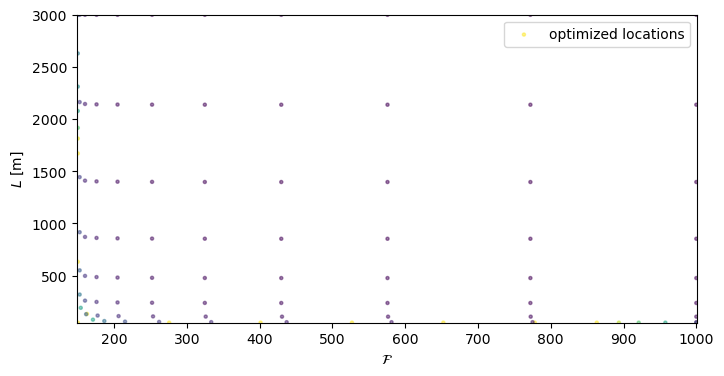

In [13]:
Fs = []
Ls = []
for i in range(Finesse_mesh.shape[0]):
    for k in range(Finesse_mesh.shape[1]):
        Fs.append(Finesse_mesh[i][k])
        Ls.append(L_mesh[i][k])

print(np.shape(Finesse_mesh))

#plt.scatter(Fs, Ls, s=1, c='red', alpha=0.5, label='equally spaced points')
plt.xlim(Finesse_min-1, Finesse_max+1)
plt.ylim(L_min-1, L_max+1)
#plt.show()

Fs = []
Ls = []
c_val = []
for i in range(F_coords_norm.shape[0]):
    for k in range(F_coords_norm.shape[1]):
        Fs.append(F_coords_norm[i][k])
        Ls.append(L_coords_norm.T[i][k])
        c_val.append(v_cr_values[i][k])

plt.scatter(Fs, Ls, c=c_val, s=5, cmap='viridis', alpha=0.5, label='optimized locations')
plt.xlim(Finesse_min-1, Finesse_max+1)
plt.ylim(L_min-1, L_max+1)
plt.xlabel('$\mathcal{F}$')
plt.ylabel('$L$ [m]')
plt.legend()

### Cavities XML file generation

The next cell generates an XML file containing information about optical cavities. It uses the `xml.etree.ElementTree` module to create an XML structure. Each cavity is represented as an XML element with the following sub-elements:

- **Finesse**: The finesse value of the cavity, taken from the `Fs` list.
- **Length**: The length of the cavity, taken from the `Ls` list.
- **UUID**: A unique identifier for the cavity, generated using the `uuid.uuid5` function based on the finesse and length values.

The XML structure is saved to a file named `optical_cavities.xml`. This file can be used for further analysis or as input for other tools that process optical cavity data.

In [14]:
import uuid
import xml.etree.ElementTree as ET

# Create the root element
root = ET.Element("OpticalCavities")

# Iterate through Fs and Ls and create an entry for each optical cavity
for f, l in zip(Fs, Ls):
    cavity = ET.SubElement(root, "Cavity")
    finesse = ET.SubElement(cavity, "Finesse")
    finesse.text = str(f)
    length = ET.SubElement(cavity, "Length")
    length.text = str(l)
    unique_id = ET.SubElement(cavity, "UUID")
    unique_id.text = str(uuid.uuid5(uuid.NAMESPACE_DNS, f"{f}-{l}"))

# Create the tree and save it to an XML file
tree = ET.ElementTree(root)
tree.write("../tests/optical_cavities.xml", encoding="utf-8", xml_declaration=True)